# CMIP6 Case A — Step 1: Exploratory Data Analysis (1985–2014)

### 中文详细说明

本 notebook 对 MPI-ESM1-2-LR historical 数据开展 1985–2014 年探索性数据分析（EDA）。当前数据包括降水 `pr`、蒸散 `evspsbl`、总径流 `mrro`、网格面积 `areacella`、陆地比例 `sftlf` 和陆地冰比例 `sftgif`。核心科学问题是：长期平均降水进入非冰盖陆地系统后，有多少以蒸散返回大气、有多少形成径流；同时单独诊断南极和格陵兰等冰盖网格。

核心水量关系为：

$$P \approx ET + R$$

这次 EDA 不是简单地画几个直方图，而是按以下顺序建立一个可以进入 tree 分析的数据基础：

1. 核对文件、变量、单位、时间和网格是否一致；
2. 修正固定变量和月度变量之间很小的坐标浮点差异；
3. 把月平均通量转换成每年的水深总量；
4. 使用模型自己的 `sftlf` 排除海洋，并用 `sftgif` 区分非冰盖陆地和永久陆地冰；
5. 将 All land、Non-ice land 和 Land ice 三套分析域并列比较，再把 Non-ice land 作为主要水文分析域；
6. 检查负 ET、零径流、ET>P 和水量平衡残差的空间位置；
7. 绘制 P、ET、R 及水量分配的全球地图和分区统计；
8. 分析 P–ET、P–R 和 P–(ET+R) 的功能关系；
9. 检查1985–2014年际变化和12个月平均季节循环；
10. 整理后续全球及分区 tree 所需的一行一网格数据表。

整个 notebook 不会修改原始 NetCDF。默认 `SAVE_TABLE=False`，因此执行时也不会自动写出新的 CSV。

This notebook performs a reproducible first-pass EDA for the MPI-ESM1-2-LR historical simulation. The core water-balance framework is:

$$P \approx ET + R$$

where **P** is precipitation (`pr`), **ET** is evaporation including sublimation and transpiration (`evspsbl`), and **R** is total runoff (`mrro`).

The notebook is organized into ten steps. Each step first explains what is being checked, why it matters, and what output to inspect. It does not modify the original NetCDF files. Optional table export is disabled by default.

Main analysis choices:

- Historical reference period: **1985–2014**
- Monthly fluxes are converted to annual totals using the exact monthly time bounds
- Ocean cells are removed using `sftlf`; prescribed land ice is identified independently with `sftgif`
- All-land, non-ice-land, and land-ice summaries are reported separately; non-ice land is the primary hydrological domain
- Spatial summaries use `areacella × sftlf/100` as the land-area weight
- Köppen-based WW/WD/CW/CD analysis is enabled automatically if `koppen_geiger_0p1.nc` is found
- The model-native `sftgif` mask, rather than an outcome-based filter, excludes permanent land ice from the primary analysis


## Step 0 — Configuration and imports

### 中文详细说明

这一部分完成 notebook 的运行配置。主要工作包括：

- 导入 `numpy`、`pandas`、`xarray`、`matplotlib`、`seaborn` 和 `scipy`；
- 将研究时段固定为1985–2014，共30年；
- 自动寻找 `case/caseA`，使 notebook 从仓库根目录或 `caseA` 目录启动时都能找到数据；
- 设置统一的绘图风格；
- 设置 `KG_OVERRIDE`，以后如果 Köppen 文件不在自动搜索位置，可以直接填入绝对路径；
- 设置 `SAVE_TABLE=False`，保证初次 EDA 只是读取和分析，不生成额外数据文件。

本 notebook 使用 `pip39` kernel，因为这个环境已经包含 xarray、绘图库和当前项目所需依赖。

This block imports the required libraries, sets the analysis period, and locates `case/caseA` regardless of whether Jupyter was started from the repository root or from the `SA` directory.

`SAVE_TABLE` is `False` by default so that running the EDA does not create additional data products unless explicitly requested.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "font.family": "DejaVu Sans",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

START_YEAR = 1985
END_YEAR = 2014
SAVE_TABLE = False
KG_OVERRIDE = None  # Example: Path("/absolute/path/to/koppen_geiger_0p1.nc")

def style_cartesian_axes(ax, grid=True):
    """Apply one consistent, publication-style frame to ordinary axes."""
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#333333")
        spine.set_linewidth(0.8)
    ax.tick_params(direction="out", length=3.5, width=0.7, color="#333333")
    ax.grid(grid, color="#E5E7EB", linewidth=0.55, alpha=0.9, zorder=0)

def find_case_dir(start=Path.cwd()):
    start = start.resolve()
    for base in (start, *start.parents):
        if base.name.lower() == "casea":
            return base
        candidate = base / "case" / "caseA"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not locate case/caseA from the current working directory.")

CASE_DIR = find_case_dir()
print(f"Case directory: {CASE_DIR}")
print(f"Analysis period: {START_YEAR}–{END_YEAR}")


## Step 1 — File inventory and metadata audit

### 中文详细说明

这一部分首先盘点当前 Case A 的全部必需数据。程序要求每个变量只匹配到一个 NetCDF，避免不小心混入不同模型、成员或版本。需要检查的六个文件是：

- `pr`：降水，包括液态和固态降水；
- `evspsbl`：蒸发、蒸腾和升华的总和；
- `mrro`：总径流，包括地表径流和土壤底部排水；
- `areacella`：每个大气网格的完整面积；
- `sftlf`：每个网格中陆地所占百分比；
- `sftgif`：每个网格中永久陆地冰所占百分比。

输出表要重点确认：P、ET 和 R 都来自 `MPI-ESM1-2-LR`、成员 `r1i1p1f1`、原生网格 `gn`，月数据覆盖1850–2014，维度都是 `1980 × 96 × 192`。固定变量应为 `96 × 192`。如果模型、成员、网格或时间不一致，就不应继续合并分析。

This step locates exactly one NetCDF file for each required variable and opens the datasets lazily with xarray. The inventory table checks:

- variable name and physical meaning
- units
- dimensions and grid size
- time coverage
- model, ensemble member, and grid label

Expected result: P, ET, and runoff should all be MPI-ESM1-2-LR, `r1i1p1f1`, `gn`, with the same 96 × 192 grid and monthly coverage from 1850 through 2014. The fixed `sftlf`, `sftgif`, and `areacella` fields must describe the same atmospheric grid.


In [2]:
def exactly_one(pattern):
    matches = sorted(CASE_DIR.glob(pattern))
    if len(matches) != 1:
        raise FileNotFoundError(f"Expected exactly one match for {pattern!r}, found {len(matches)}: {matches}")
    return matches[0]

def exactly_one_of(*patterns):
    matches = sorted({path for pattern in patterns for path in CASE_DIR.glob(pattern)})
    if len(matches) != 1:
        raise FileNotFoundError(f"Expected exactly one match across {patterns!r}, found {len(matches)}: {matches}")
    return matches[0]

FILES = {
    "P": exactly_one("P/pr_*.nc"),
    "ET": exactly_one("ET/evspsbl_*.nc"),
    "R": exactly_one("Runoff/mrro_*.nc"),
    "area": exactly_one("areacella/areacella_*.nc"),
    "land": exactly_one("sftlf/sftlf_*.nc"),
    "ice": exactly_one_of("sftgif/sftgif_*.nc", "sftgif_*.nc"),
}
VAR_NAMES = {"P": "pr", "ET": "evspsbl", "R": "mrro", "area": "areacella", "land": "sftlf", "ice": "sftgif"}
DATASETS = {key: xr.open_dataset(path) for key, path in FILES.items()}

inventory = []
for key, ds in DATASETS.items():
    var = ds[VAR_NAMES[key]]
    inventory.append({
        "key": key,
        "file": FILES[key].name,
        "variable": VAR_NAMES[key],
        "long_name": var.attrs.get("long_name"),
        "units": var.attrs.get("units"),
        "shape": str(var.shape),
        "time_start": str(ds.time.values[0])[:10] if "time" in ds.coords else "fixed",
        "time_end": str(ds.time.values[-1])[:10] if "time" in ds.coords else "fixed",
        "source_id": ds.attrs.get("source_id"),
        "variant": ds.attrs.get("variant_label"),
        "grid": ds.attrs.get("grid_label"),
    })
inventory_df = pd.DataFrame(inventory)
display(inventory_df)


,key,file,variable,long_name,units,shape,time_start,time_end,source_id,variant,grid
0,P,pr_Amon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn_1...,pr,Precipitation,kg m-2 s-1,"(1980, 96, 192)",1850-01-16,2014-12-16,MPI-ESM1-2-LR,r1i1p1f1,gn
1,ET,evspsbl_Amon_MPI-ESM1-2-LR_historical_r1i1p1f1...,evspsbl,Evaporation Including Sublimation and Transpir...,kg m-2 s-1,"(1980, 96, 192)",1850-01-16,2014-12-16,MPI-ESM1-2-LR,r1i1p1f1,gn
2,R,mrro_Lmon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn...,mrro,Total Runoff,kg m-2 s-1,"(1980, 96, 192)",1850-01-16,2014-12-16,MPI-ESM1-2-LR,r1i1p1f1,gn
3,area,areacella_fx_MPI-ESM1-2-LR_historical_r1i1p1f1...,areacella,Grid-Cell Area for Atmospheric Grid Variables,m2,"(96, 192)",fixed,fixed,MPI-ESM1-2-LR,r1i1p1f1,gn
4,land,sftlf_fx_MPI-ESM1-2-LR_historical_r1i1p1f1_gn.nc,sftlf,Percentage of the grid cell occupied by land ...,%,"(96, 192)",fixed,fixed,MPI-ESM1-2-LR,r1i1p1f1,gn
5,ice,sftgif_fx_MPI-ESM1-2-LR_historical_r1i1p1f1_gn.nc,sftgif,Land Ice Area Percentage,%,"(96, 192)",fixed,fixed,MPI-ESM1-2-LR,r1i1p1f1,gn


## Step 2 — Coordinate harmonization and model land mask

### 中文详细说明

虽然 P、ET、R、`areacella`、`sftlf` 和 `sftgif` 都描述同一个 `96 × 192` 大气网格，但下载来源可能使用不同经度表示：现有 CDS 文件为 −180–180°，CEDA 的 `sftgif` 为0–360°；纬度还可能存在约 $10^{-14}$ 的浮点差异。若直接交给 xarray 对齐，可能错位或丢失网格，因此必须先统一经度并核对坐标。

处理逻辑是：

1. 将所有经度统一为 $[-180,180)$ 并排序；
2. 检查所有变量的纬度和经度长度是否一致；
3. 使用 `np.allclose` 确认剩余差异只是机器精度，而不是实际网格不同；
4. 将 P、ET、R、`areacella` 和 `sftgif` 坐标统一赋值为 `sftlf` 坐标；
5. 定义 `land_mask`、`ice_mask` 和 `non_ice_mask`；
6. 计算有效陆地面积：$A_{land}=A_{cell}\times sftlf/100$。

面积权重非常重要。经纬度网格在高纬度面积更小，如果把每个网格等权处理，加拿大、俄罗斯、格陵兰和南极会被过度代表。当前 MPI 的 `sftlf` 和 `sftgif` 都只有0和100，因此可以用模型原生固定场明确区分普通陆地与格陵兰、南极等永久冰盖，而不需要根据负 ET 或水量残差反向筛选。

The fixed fields and monthly fields describe the same physical grid, but they can use 0–360° versus −180–180° longitudes and can differ at machine precision in latitude. Exact xarray alignment can therefore shift or silently remove coordinates.

This block first normalizes every longitude axis to $[-180,180)$, verifies numerical compatibility with `np.allclose`, and then assigns the `sftlf` coordinates to all variables. It creates separate all-land, non-ice-land, and land-ice masks and calculates the effective land-area weight:

$$A_{land}=A_{cell}\times\frac{sftlf}{100}$$

For this MPI file, `sftlf` is expected to be binary (0 or 100), but the formula also supports fractional coastal cells.


In [3]:
def normalize_longitude(da):
    """Normalize every longitude axis to [-180, 180) before xarray alignment."""
    if "lon" not in da.coords:
        return da
    normalized_lon = ((da.lon + 180) % 360) - 180
    return da.assign_coords(lon=normalized_lon).sortby("lon")

sftlf = normalize_longitude(DATASETS["land"]["sftlf"])
sftgif = normalize_longitude(DATASETS["ice"]["sftgif"])
areacella = normalize_longitude(DATASETS["area"]["areacella"])
ref_lat, ref_lon = sftlf.lat, sftlf.lon

def harmonize_horizontal_coords(da, name):
    da = normalize_longitude(da)
    if da.sizes.get("lat") != ref_lat.size or da.sizes.get("lon") != ref_lon.size:
        raise ValueError(f"{name}: horizontal shape does not match sftlf.")
    lat_diff = float(np.max(np.abs(da.lat.values - ref_lat.values)))
    lon_diff = float(np.max(np.abs(da.lon.values - ref_lon.values)))
    if not np.allclose(da.lat.values, ref_lat.values, atol=1e-10, rtol=0):
        raise ValueError(f"{name}: latitude coordinates are not numerically compatible.")
    if not np.allclose(da.lon.values, ref_lon.values, atol=1e-10, rtol=0):
        raise ValueError(f"{name}: longitude coordinates are not numerically compatible.")
    print(f"{name}: max coordinate difference lat={lat_diff:.3e}, lon={lon_diff:.3e}")
    return da.assign_coords(lat=ref_lat, lon=ref_lon)

P_flux = harmonize_horizontal_coords(DATASETS["P"]["pr"], "P")
ET_flux = harmonize_horizontal_coords(DATASETS["ET"]["evspsbl"], "ET")
R_flux = harmonize_horizontal_coords(DATASETS["R"]["mrro"], "R")
areacella = harmonize_horizontal_coords(areacella, "areacella")
sftgif = harmonize_horizontal_coords(sftgif, "sftgif")

land_mask = sftlf > 0
ice_mask = land_mask & (sftgif > 0)
non_ice_mask = land_mask & ~ice_mask
land_area = (areacella * sftlf / 100).where(land_mask, 0).rename("land_area")
ice_area = (areacella * sftgif / 100).where(ice_mask, 0).rename("ice_area")
land_values = np.unique(sftlf.values[np.isfinite(sftlf.values)])
ice_values = np.unique(sftgif.values[np.isfinite(sftgif.values)])

mask_summary = pd.Series({
    "total_grid_cells": int(sftlf.size),
    "land_grid_cells": int(land_mask.sum()),
    "non_ice_land_cells": int(non_ice_mask.sum()),
    "land_ice_cells": int(ice_mask.sum()),
    "ocean_grid_cells": int((~land_mask).sum()),
    "sftlf_unique_values": land_values.tolist(),
    "sftgif_unique_values": ice_values.tolist(),
    "earth_area_million_km2": float(areacella.sum() / 1e12),
    "land_area_million_km2": float(land_area.sum() / 1e12),
    "land_ice_area_million_km2": float(ice_area.sum() / 1e12),
    "non_ice_land_area_million_km2": float((land_area - ice_area).sum() / 1e12),
    "land_fraction": float(land_area.sum() / areacella.sum()),
})
display(mask_summary.to_frame("value"))


P: max coordinate difference lat=1.421e-14, lon=0.000e+00
ET: max coordinate difference lat=1.421e-14, lon=0.000e+00
R: max coordinate difference lat=1.421e-14, lon=0.000e+00
areacella: max coordinate difference lat=0.000e+00, lon=0.000e+00
sftgif: max coordinate difference lat=0.000e+00, lon=0.000e+00


,value
total_grid_cells,18432
land_grid_cells,6222
non_ice_land_cells,4172
land_ice_cells,2050
ocean_grid_cells,12210
sftlf_unique_values,"[0.0, 100.0]"
sftgif_unique_values,"[0.0, 100.0]"
earth_area_million_km2,510.064444
land_area_million_km2,147.102076
land_ice_area_million_km2,15.767745


## Step 3 — Convert monthly fluxes to annual water totals

### 中文详细说明

P、ET 和 R 都是月平均通量，单位为 `kg m⁻² s⁻¹`。水深换算中 $1\ kg\ m^{-2}=1\ mm$，因此每月水量为：

$$X_{month}=X_{flux}\times\Delta t$$

其中 $\Delta t$ 不是统一假设为30天，而是直接从每个月的 `time_bnds` 读取起止时间并计算秒数。这样可以正确处理不同月份长度，也兼容气候模型可能使用的非标准日历。

转换顺序是：

1. 截取1985年1月至2014年12月，共360个月；
2. 将每个月的平均通量乘以该月秒数，得到 `mm/month`；
3. 每12个月求和，得到30个 `mm/year` 年度总量；
4. 对30年年度值求平均，得到每个网格的长期平均 P、ET 和 R；
5. 计算长期平均水量平衡残差 $P-ET-R$。

这里先按年累加再求30年平均，比直接对360个月普通平均后乘365更严谨。

The monthly variables are mean fluxes in `kg m⁻² s⁻¹`. Because 1 kg m⁻² of water is equivalent to 1 mm of water depth, multiplying each monthly mean flux by the exact number of seconds represented by its time bounds gives `mm/month`. Summing the twelve monthly amounts gives `mm/year`.

This is preferable to multiplying a simple monthly average by 365 because months have different lengths and climate models can use different calendars.

The block verifies that 1985–2014 contains exactly 360 months and 30 complete years.


In [4]:
def annual_totals_from_flux(da, ds, start_year=START_YEAR, end_year=END_YEAR):
    selected = da.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    bounds = ds["time_bnds"].sel(time=selected.time)
    seconds = (bounds.isel(bnds=1) - bounds.isel(bnds=0)) / np.timedelta64(1, "s")
    monthly_amount = (selected * seconds).assign_attrs(units="mm month-1")
    counts = selected.time.groupby("time.year").count()
    if selected.sizes["time"] != (end_year - start_year + 1) * 12:
        raise ValueError("The selected period does not contain the expected number of months.")
    if not np.all(counts.values == 12):
        raise ValueError("At least one selected year does not contain exactly 12 months.")
    annual = monthly_amount.groupby("time.year").sum("time", skipna=False)
    return annual.assign_attrs(units="mm year-1"), monthly_amount

P_annual, P_monthly_amount = annual_totals_from_flux(P_flux, DATASETS["P"])
ET_annual, ET_monthly_amount = annual_totals_from_flux(ET_flux, DATASETS["ET"])
R_annual, R_monthly_amount = annual_totals_from_flux(R_flux, DATASETS["R"])

P_clim = P_annual.mean("year").rename("P")
ET_clim = ET_annual.mean("year").rename("ET")
R_clim = R_annual.mean("year").rename("R")
WB_clim = (P_clim - ET_clim - R_clim).rename("water_balance_residual")

print(f"Annual arrays: {P_annual.shape}; years {int(P_annual.year.min())}–{int(P_annual.year.max())}")
print("Climatology units: mm year-1")


Annual arrays: (30, 96, 192); years 1985–2014
Climatology units: mm year-1


## Step 4 — Optional Köppen proxy zones and the final analysis mask

### 中文详细说明

这一步先把 `non_ice_mask` 设为主要水文分析域，再可选建立后续分区分析所需的 Köppen-based proxy。永久冰盖由模型原生 `sftgif` 独立识别，不再依赖 Köppen EF 作为唯一冰盖筛选。Köppen 是离散类别，重新匹配网格时只能使用最近邻，不能使用双线性插值，否则会生成不存在的类别编码。

本 Case 暂时采用以下映射：

- **WW（Warm–Wet）**：Af、Am、Cwa、Cwb、Cfa、Cfb，对应代码1、2、11、12、14、15；
- **WD（Warm–Dry）**：Aw、BWh、BSh、Csa、Csb，对应代码3、4、6、8、9；
- **CW（Cold–Wet）**：Cfc、Dfa、Dfb、Dfc、Dfd、ET，对应代码16、25、26、27、28、29；
- **CD（Cold–Dry）**：BWk、BSk、Csc、Cwc、Dsa–Dsd、Dwa–Dwd，对应代码5、7、10、13、17–24；
- 代码0和 EF（代码30）排除。

分离陆地冰很重要，因为这些网格中的 `evspsbl` 包含升华、凝结和沉积，`mrro` 也常为0，不能与普通陆地 P–ET–R 过程混在一起。`sftgif` 负责物理掩膜；Köppen EF 仅作为分类信息。ET 苔原则暂时归入 CW，因为其水循环通常更接近能量限制。

这套分类只叫 **Köppen-based proxy**，不能声称等同于论文中根据净辐射/降水比和温度得到的原始 WW/WD/CW/CD。如果当前找不到 Köppen 文件，程序不会报错退出，而是继续完成 Non-ice land EDA，并跳过 Köppen 分区表格与分区图。

The model-native `sftgif` field first defines non-ice land as the primary hydrological domain. This step then searches for `koppen_geiger_0p1.nc`. If found, the categorical raster is matched to that domain using nearest-neighbour interpolation and converted to the agreed four-region proxy:

| Zone | Köppen classes | Codes |
|---|---|---|
| WW | Af, Am, Cwa, Cwb, Cfa, Cfb | 1, 2, 11, 12, 14, 15 |
| WD | Aw, BWh, BSh, Csa, Csb | 3, 4, 6, 8, 9 |
| CW | Cfc, Dfa, Dfb, Dfc, Dfd, ET | 16, 25, 26, 27, 28, 29 |
| CD | BWk, BSk, Csc, Cwc, Dsa–Dsd, Dwa–Dwd | 5, 7, 10, 13, 17–24 |
| Excluded | ocean/unknown and permanent frost | 0, 30 |

This is a **Köppen-based proxy**, not the original net-radiation/precipitation classification. If the Köppen file is unavailable, the notebook continues with model-defined non-ice land and clearly labels the zone analysis as unavailable.


In [5]:
ZONE_ORDER = ["WW", "WD", "CW", "CD"]
ZONE_COLORS = {"WW": "#078C78", "WD": "#A85F12", "CW": "#73C9C2", "CD": "#DFC27D"}
KOPPEN_TO_ZONE = {
    **{code: "WW" for code in [1, 2, 11, 12, 14, 15]},
    **{code: "WD" for code in [3, 4, 6, 8, 9]},
    **{code: "CW" for code in [16, 25, 26, 27, 28, 29]},
    **{code: "CD" for code in [5, 7, 10, 13, 17, 18, 19, 20, 21, 22, 23, 24]},
}

def locate_koppen_file():
    if KG_OVERRIDE is not None:
        path = Path(KG_OVERRIDE).expanduser().resolve()
        return path if path.exists() else None
    search_roots = [CASE_DIR, CASE_DIR.parent.parent]
    matches = []
    for root in search_roots:
        matches.extend(root.rglob("koppen_geiger_0p1.nc"))
    return sorted(set(matches))[0] if matches else None

KG_PATH = locate_koppen_file()
zone_available = KG_PATH is not None

if zone_available:
    kg_ds = xr.open_dataset(KG_PATH)
    kg_var = list(kg_ds.data_vars)[0]
    kg = normalize_longitude(kg_ds[kg_var].squeeze()).sortby("lat")
    kg_on_cmip = kg.interp(lat=ref_lat, lon=ref_lon, method="nearest").round().astype("int16")
    zone_values = np.full(kg_on_cmip.shape, "Excluded", dtype=object)
    for code, label in KOPPEN_TO_ZONE.items():
        zone_values[kg_on_cmip.values == code] = label
    zone = xr.DataArray(zone_values, coords={"lat": ref_lat, "lon": ref_lon}, dims=("lat", "lon"), name="zone")
    analysis_mask = non_ice_mask & zone.isin(ZONE_ORDER)
    print(f"Köppen file: {KG_PATH}")
    print("Final analysis cells by zone:")
    print(pd.Series(zone.where(analysis_mask).values.ravel()).value_counts().reindex(ZONE_ORDER))
else:
    zone = xr.full_like(sftlf, "Not available", dtype=object).rename("zone")
    analysis_mask = non_ice_mask.copy()
    print("Köppen file not found: continuing with non-ice land cells.")
    print("Zone-specific blocks will be skipped until KG_OVERRIDE is set or the file is added.")


Köppen file not found: continuing with non-ice land cells.
Zone-specific blocks will be skipped until KG_OVERRIDE is set or the file is added.


## Step 5 — Tidy grid-cell table and quality-control flags

### 中文详细说明

这一步把二维气候网格整理成后续统计可直接使用的一行一网格表格。表格保留全部陆地网格，并用字段区分 Non-ice land 与 Land ice；主要分析表只选择 Non-ice land，但冰盖数据不会从原始表中删除。每一行包含：

- `lat`、`lon`：网格中心坐标；
- `cell_area`、`land_area`：完整网格面积和有效陆地面积；
- `sftgif`、`surface_class`：陆地冰比例以及 Non-ice land/Land ice 标签；
- `zone`：WW、WD、CW、CD 或 Not available；
- `P`、`ET`、`R`：1985–2014平均年度水深；
- `WB=P−ET−R`：长期水量平衡残差；
- `ET/P` 和 `R/P`：降水在蒸散与径流之间的分配比例。

同时检查以下 QC 标志：缺失值、负 P、负 ET、负 R、零径流、ET>P，以及绝对水量残差大于10 mm/year。这里的原则是**先标记、先画地图、后决定是否排除**。

负 ET 不应直接改成0，因为它可能表示冰雪表面的水汽沉积或凝结；零径流在荒漠或冻结区也可能真实存在；ET>P 在个别网格可能与侧向水分输送、储量变化或数值误差有关。只有确认空间位置和物理来源后才能制定清洗规则。ET/P 和 R/P 在所有 P>0 的局地网格上计算并完整保留，不额外设置降水阈值，也不删除极干旱区。

This block creates one row per CMIP grid cell with coordinates, area, `sftgif`, surface class, zone, P, ET, runoff, and derived water-balance metrics. Separate frames are retained for all land, non-ice land, and land ice. The main diagnostic is:

$$WB=P-ET-R$$

Quality flags are counted but not automatically deleted. Negative ET can represent deposition/condensation over ice-covered regions, and zero runoff can be physically valid in dry or frozen regions. Their locations should be inspected before making exclusions.

ET/P and R/P are calculated and retained for every local grid cell with positive precipitation. No additional precipitation threshold is applied, so hyper-arid regions remain part of the spatial analysis.


In [6]:
ET_over_P = xr.where(P_clim > 0, ET_clim / P_clim, np.nan).rename("ET_over_P")
R_over_P = xr.where(P_clim > 0, R_clim / P_clim, np.nan).rename("R_over_P")

surface_values = np.full(sftlf.shape, "Ocean", dtype=object)
surface_values[non_ice_mask.values] = "Non-ice land"
surface_values[ice_mask.values] = "Land ice"
surface_class = xr.DataArray(surface_values, coords={"lat": ref_lat, "lon": ref_lon}, dims=("lat", "lon"), name="surface_class")

grid_ds = xr.Dataset({
    "land_fraction": sftlf,
    "land_ice_fraction": sftgif,
    "cell_area": areacella,
    "land_area": land_area,
    "ice_area": ice_area,
    "surface_class": surface_class,
    "zone": zone,
    "land_cell": land_mask,
    "non_ice_cell": non_ice_mask,
    "ice_cell": ice_mask,
    "analysis_cell": analysis_mask,
    "P": P_clim,
    "ET": ET_clim,
    "R": R_clim,
    "WB": WB_clim,
    "ET_over_P": ET_over_P,
    "R_over_P": R_over_P,
})
grid_df = grid_ds.to_dataframe().reset_index()
grid_df["negative_ET"] = grid_df["ET"] < 0
grid_df["zero_R"] = grid_df["R"] == 0
grid_df["ET_greater_than_P"] = grid_df["ET"] > grid_df["P"]
grid_df["large_WB"] = grid_df["WB"].abs() > 10
land_df = grid_df.loc[grid_df["land_cell"]].copy()
non_ice_df = grid_df.loc[grid_df["non_ice_cell"]].copy()
ice_df = grid_df.loc[grid_df["ice_cell"]].copy()
analysis_df = grid_df.loc[grid_df["analysis_cell"]].copy()

def qc_counts(frame):
    return pd.Series({
        "cells": len(frame),
        "area_million_km2": frame["land_area"].sum() / 1e12,
        "missing_any_P_ET_R": int(frame[["P", "ET", "R"]].isna().any(axis=1).sum()),
        "P_negative": int((frame["P"] < 0).sum()),
        "ET_negative": int((frame["ET"] < 0).sum()),
        "R_negative": int((frame["R"] < 0).sum()),
        "R_zero": int((frame["R"] == 0).sum()),
        "ET_greater_than_P": int((frame["ET"] > frame["P"]).sum()),
        "abs_WB_greater_than_10_mm_yr": int((frame["WB"].abs() > 10).sum()),
    })

domain_frames = {"All land": land_df, "Non-ice land": non_ice_df, "Land ice": ice_df}
qc_by_domain_df = pd.DataFrame({name: qc_counts(frame) for name, frame in domain_frames.items()}).T
display(qc_by_domain_df.round(3))

flagged = land_df.loc[
    (land_df["ET"] < 0) | (land_df["ET"] > land_df["P"]) | (land_df["WB"].abs() > 10),
    ["lat", "lon", "surface_class", "zone", "P", "ET", "R", "WB", "ET_over_P"]
].sort_values("WB", key=np.abs, ascending=False)
display(flagged.head(15))


,cells,area_million_km2,missing_any_P_ET_R,P_negative,ET_negative,R_negative,R_zero,ET_greater_than_P,abs_WB_greater_than_10_mm_yr
All land,6222.0,147.102,0.0,0.0,1501.0,0.0,2050.0,44.0,2099.0
Non-ice land,4172.0,131.334,0.0,0.0,0.0,0.0,0.0,44.0,49.0
Land ice,2050.0,15.768,0.0,0.0,1501.0,0.0,2050.0,0.0,2050.0


,lat,lon,surface_class,zone,P,ET,R,WB,ET_over_P
15818,64.350730,-41.250,Land ice,Not available,1836.059677,31.998292,0.0,1804.061386,0.017428
15625,62.485571,-43.125,Land ice,Not available,1766.052546,10.859051,0.0,1755.193495,0.006149
15433,60.620396,-43.125,Land ice,Not available,1635.710090,-50.384153,0.0,1686.094242,-0.030803
15432,60.620396,-45.000,Land ice,Not available,1366.479404,-13.508005,0.0,1379.987408,-0.009885
15381,60.620396,-140.625,Land ice,Not available,1301.807360,-19.151839,0.0,1320.959199,-0.014712
16012,66.215872,-37.500,Land ice,Not available,1331.439994,60.121418,0.0,1271.318576,0.045155
16011,66.215872,-39.375,Land ice,Not available,1249.716421,24.813633,0.0,1224.902788,0.019855
16013,66.215872,-35.625,Land ice,Not available,1286.149015,68.960056,0.0,1217.188960,0.053617
15624,62.485571,-45.000,Land ice,Not available,1167.056945,5.594820,0.0,1161.462125,0.004794
15817,64.350730,-43.125,Land ice,Not available,1165.202213,4.327904,0.0,1160.874309,0.003714


## Step 6 — Spatial maps of the water cycle and QC diagnostics

### 中文详细说明

空间地图是判断数据问题最重要的一步，因为同一个异常数值出现在南极冰盖和出现在亚马孙雨林，其物理含义完全不同。程序先绘制模型原生 `sftgif`，确认格陵兰和南极冰盖位置；随后只在 Non-ice land 上绘制主要水循环地图：

1. 1985–2014平均年降水 P；
2. 平均年蒸散 ET；
3. 平均年径流 R；
4. 水量平衡残差 $P-ET-R$；
5. 蒸散分配比例 ET/P；
6. 径流分配比例 R/P。

P、ET 和 R 的颜色范围使用有效分析网格的1%–99%分位数，避免极少数极值把大部分地图压成同一种颜色。残差图使用以0为中心的发散色带。ET/P 和 R/P 地图显示所有 P>0 的非冰盖局地网格；固定0–1色标仅用于保持水分分配含义清晰，超出范围的值仍保留在数据表和 QC 中。

第二组 QC 地图在 All land 上显示负 ET、零径流、ET>P 和 $|P-ET-R|>10$ mm/year，并用深色轮廓标出 `sftgif` 冰盖边界。这样可以直接判断异常是否由南极和格陵兰贡献；Non-ice land 中残留的异常才需要进一步检查变量定义、单位换算和网格匹配。

The first figure verifies the prescribed `sftgif` land-ice mask. The main figure then maps the three primary climatologies and three derived diagnostics over non-ice land:

1. mean annual precipitation
2. mean annual evapotranspiration
3. mean annual runoff
4. water-balance residual `P − ET − R`
5. ET/P
6. R/P

Robust 1st–99th percentile colour limits prevent a small number of extremes from flattening the global colour scale. ET/P and R/P maps retain every non-ice grid cell with P > 0. The QC figure uses all land and overlays the land-ice boundary so that cryosphere processes can be distinguished from isolated non-ice problems.


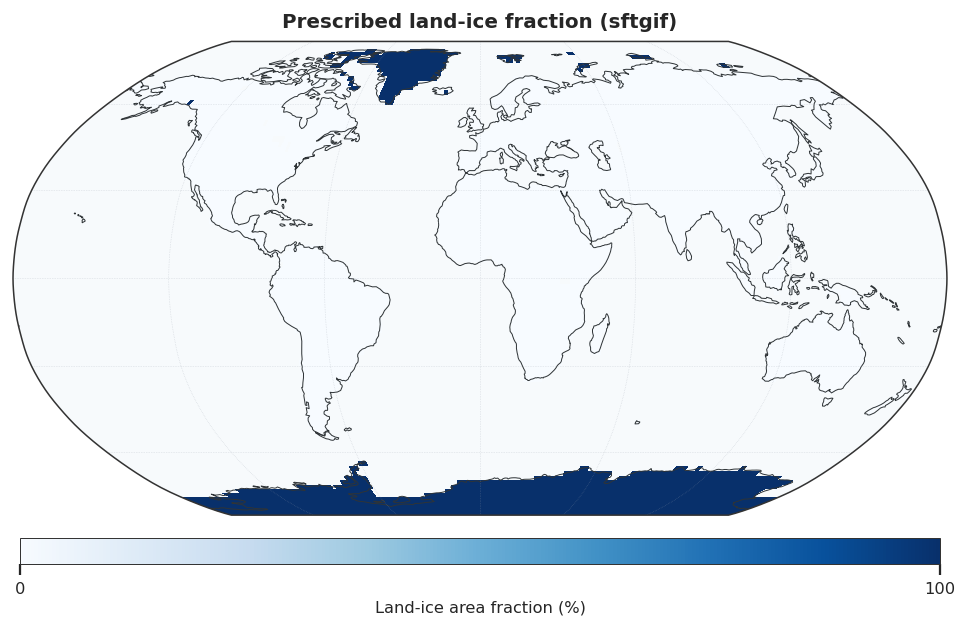

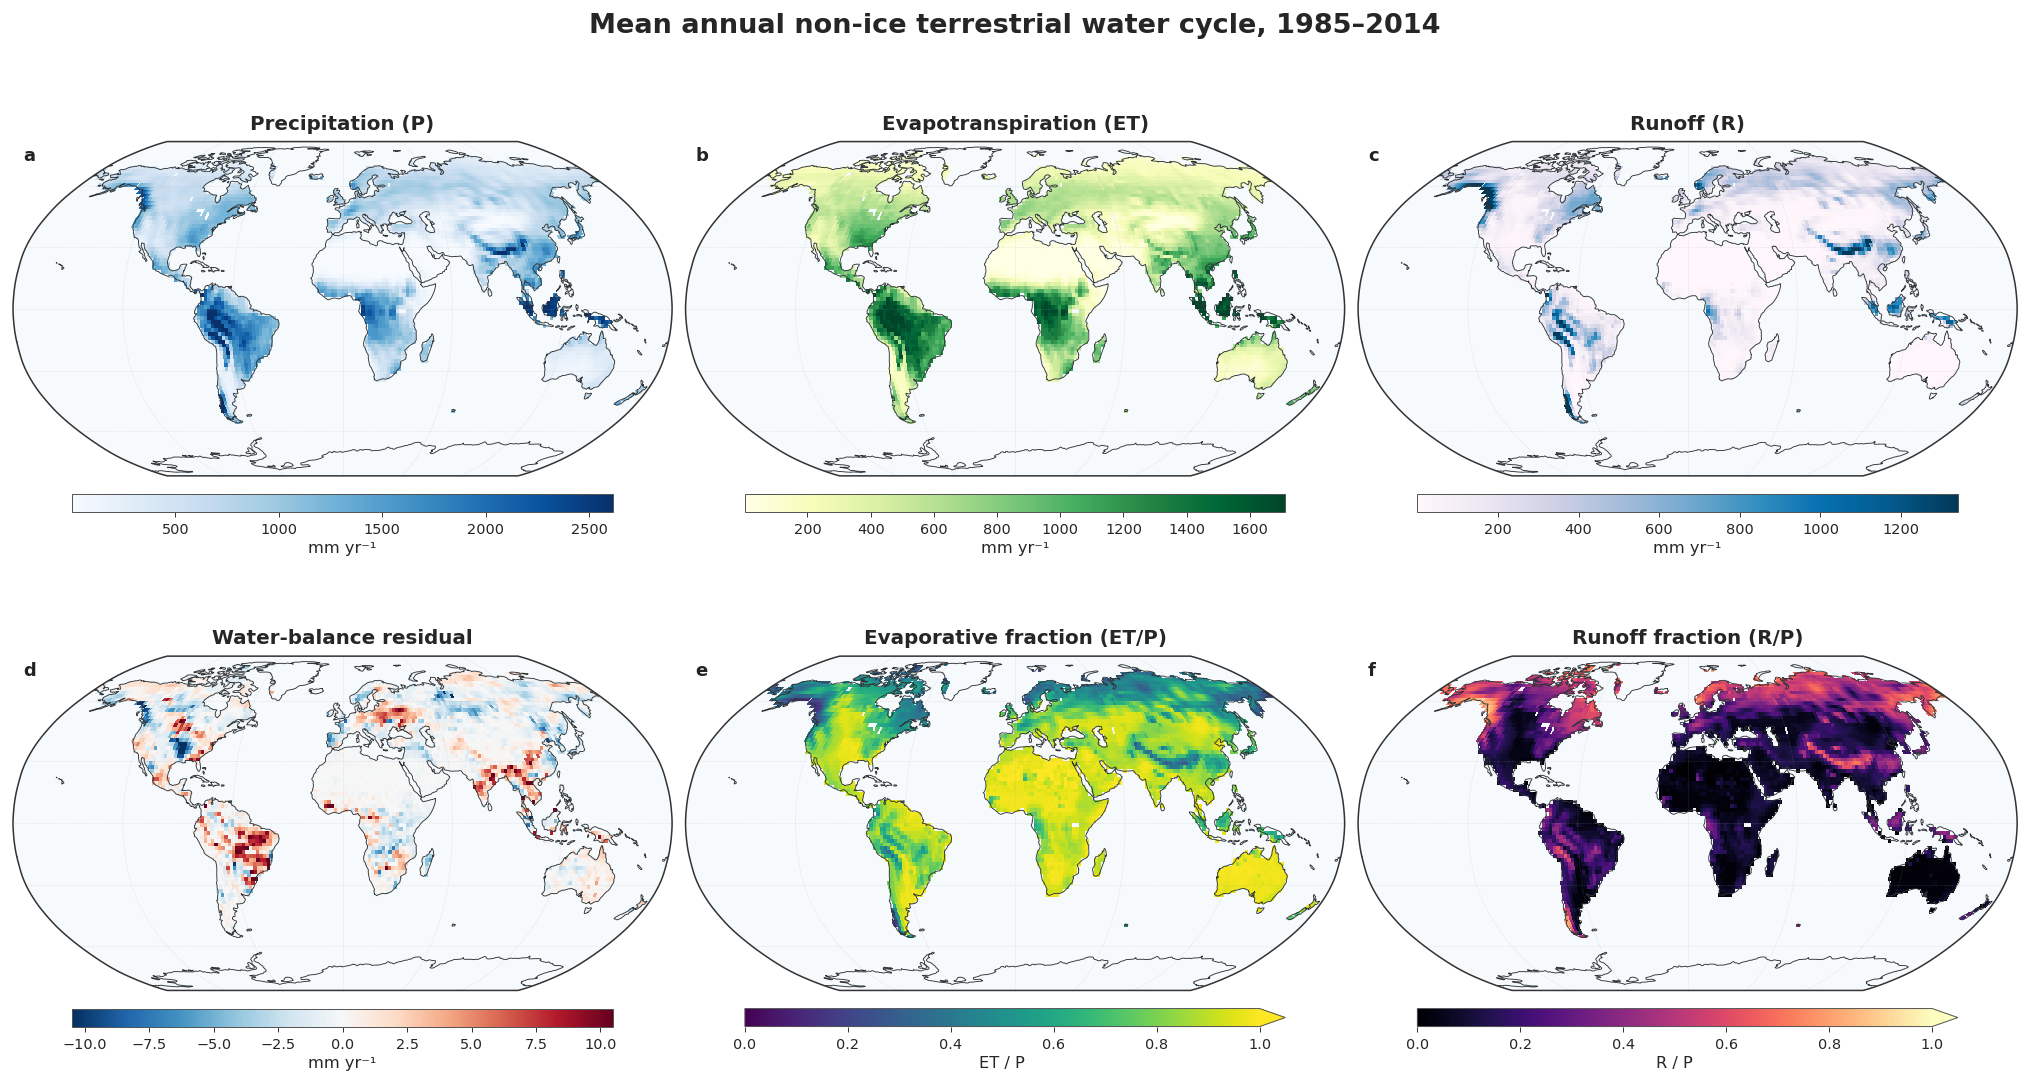

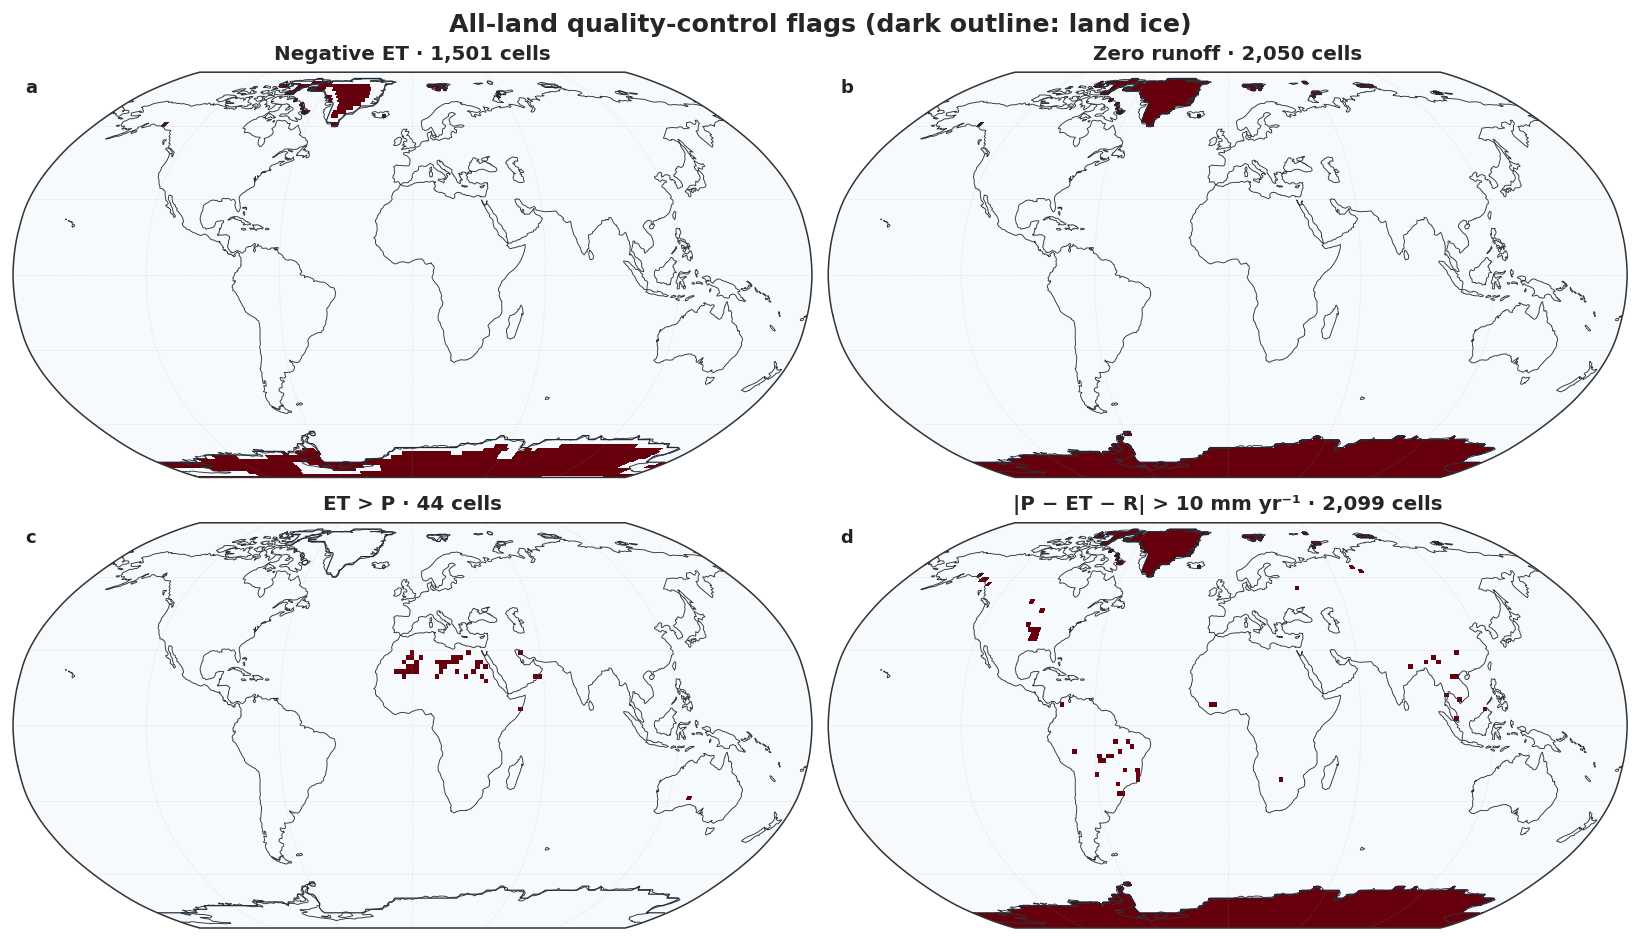

In [7]:
def robust_limits(da, mask, symmetric=False):
    values = da.where(mask).values
    values = values[np.isfinite(values)]
    if symmetric:
        vmax = np.nanquantile(np.abs(values), 0.99)
        return -vmax, vmax
    return tuple(np.nanquantile(values, [0.01, 0.99]))

map_specs = [
    {"data": P_clim, "title": "Precipitation (P)", "cmap": "Blues", "unit": "mm yr⁻¹"},
    {"data": ET_clim, "title": "Evapotranspiration (ET)", "cmap": "YlGn", "unit": "mm yr⁻¹"},
    {"data": R_clim, "title": "Runoff (R)", "cmap": "PuBu", "unit": "mm yr⁻¹"},
    {"data": WB_clim, "title": "Water-balance residual", "cmap": "RdBu_r", "unit": "mm yr⁻¹", "symmetric": True},
    {"data": ET_over_P, "title": "Evaporative fraction (ET/P)", "cmap": "viridis", "unit": "ET / P", "limits": (0, 1), "extend": "max"},
    {"data": R_over_P, "title": "Runoff fraction (R/P)", "cmap": "magma", "unit": "R / P", "limits": (0, 1), "extend": "max"},
]

projection = ccrs.Robinson()
data_crs = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(11.5, 4.7), subplot_kw={"projection": projection}, constrained_layout=True)
ice_mesh = ax.pcolormesh(ref_lon, ref_lat, sftgif.where(land_mask), transform=data_crs, shading="auto",
                         cmap="Blues", vmin=0, vmax=100, rasterized=True)
ax.set_global()
ax.set_facecolor("#F7FAFC")
ax.coastlines(resolution="110m", linewidth=0.55, color="#2F3437")
ax.gridlines(linewidth=0.35, color="#9CA3AF", alpha=0.45, linestyle=":")
ax.spines["geo"].set_edgecolor("#333333")
ax.spines["geo"].set_linewidth(0.85)
ax.set_title("Prescribed land-ice fraction (sftgif)", pad=8)
ice_cbar = fig.colorbar(ice_mesh, ax=ax, orientation="horizontal", shrink=0.62, pad=0.04, aspect=35, ticks=[0, 100])
ice_cbar.set_label("Land-ice area fraction (%)", fontsize=9, labelpad=2)
ice_cbar.outline.set_linewidth(0.55)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15.5, 8.2), subplot_kw={"projection": projection}, constrained_layout=True)
for panel, (ax, spec) in enumerate(zip(axes.ravel(), map_specs)):
    da = spec["data"]
    if "limits" in spec:
        vmin, vmax = spec["limits"]
    else:
        vmin, vmax = robust_limits(da, analysis_mask, symmetric=spec.get("symmetric", False))
    mesh = ax.pcolormesh(
        ref_lon, ref_lat, da.where(analysis_mask), transform=data_crs, shading="auto",
        cmap=spec["cmap"], vmin=vmin, vmax=vmax, rasterized=True,
    )
    ax.set_global()
    ax.set_facecolor("#F7FAFC")
    ax.coastlines(resolution="110m", linewidth=0.50, color="#2F3437")
    ax.gridlines(linewidth=0.35, color="#9CA3AF", alpha=0.45, linestyle=":")
    ax.spines["geo"].set_edgecolor("#333333")
    ax.spines["geo"].set_linewidth(0.85)
    ax.set_title(spec["title"], pad=7)
    ax.text(0.015, 0.985, chr(97 + panel), transform=ax.transAxes, va="top", ha="left",
            fontsize=10, fontweight="bold", color="#222222",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "pad": 2})
    cbar = fig.colorbar(mesh, ax=ax, orientation="horizontal", shrink=0.82, pad=0.035, aspect=30, extend=spec.get("extend", "neither"))
    cbar.set_label(spec["unit"], fontsize=9, labelpad=2)
    cbar.outline.set_edgecolor("#555555")
    cbar.outline.set_linewidth(0.55)
    cbar.ax.tick_params(labelsize=8, length=2.5, width=0.5)
fig.suptitle("Mean annual non-ice terrestrial water cycle, 1985–2014", fontsize=15, fontweight="semibold")
plt.show()

qc_maps = [
    ((ET_clim < 0) & land_mask, "Negative ET"),
    ((R_clim == 0) & land_mask, "Zero runoff"),
    ((ET_clim > P_clim) & land_mask, "ET > P"),
    ((np.abs(WB_clim) > 10) & land_mask, "|P − ET − R| > 10 mm yr⁻¹"),
]
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.2), subplot_kw={"projection": projection}, constrained_layout=True)
for panel, (ax, (flag, title)) in enumerate(zip(axes.ravel(), qc_maps)):
    ax.pcolormesh(ref_lon, ref_lat, flag.where(flag), transform=data_crs, shading="auto", cmap="Reds", vmin=0, vmax=1, rasterized=True)
    ax.contour(ref_lon, ref_lat, ice_mask.astype(int), levels=[0.5], transform=data_crs,
               colors="#1F2937", linewidths=0.65)
    ax.set_global()
    ax.set_facecolor("#F7FAFC")
    ax.coastlines(resolution="110m", linewidth=0.50, color="#2F3437")
    ax.gridlines(linewidth=0.35, color="#9CA3AF", alpha=0.45, linestyle=":")
    ax.spines["geo"].set_edgecolor("#333333")
    ax.spines["geo"].set_linewidth(0.85)
    ax.set_title(f"{title} · {int(flag.sum()):,} cells", pad=7)
    ax.text(0.015, 0.985, chr(97 + panel), transform=ax.transAxes, va="top", ha="left",
            fontsize=10, fontweight="bold", color="#222222")
fig.suptitle("All-land quality-control flags (dark outline: land ice)", fontsize=14, fontweight="semibold")
plt.show()


## Step 7 — Area-weighted distributions and regional summary table

### 中文详细说明

这一部分从地图进入定量分布比较。因为当前是规则经纬度网格，高纬网格面积远小于低纬网格，所以全球均值、中位数和分位数都使用 `land_area` 作为权重，而不是把6222个陆地网格简单等权。

All land、Non-ice land、Land ice 先分别统计；如果 Köppen 数据可用，再对 WW、WD、CW、CD 分别统计：

- 有效网格数；
- 覆盖陆地面积；
- 面积加权均值；
- 加权5%、25%、50%、75%和95%分位数；
- P、ET、R、WB、ET/P 和 R/P。

面积加权直方图用于观察偏态、长尾、双峰和大量零值。径流通常高度右偏，因此后续可以增加 `log1p(R)` 辅助图，但原始报告仍保留 `mm/year`。第一次 EDA 不删除每区前后1%的极端网格，因为极端干旱、极端湿润和高山/冰雪格点可能正是重要的气候过程；应先理解其空间来源，再做保留与剔除的敏感性比较。

Equal-angle climate grids contain many small high-latitude cells and fewer large tropical cells. Unweighted statistics therefore over-represent high latitudes. This step calculates area-weighted means and weighted quantiles using the effective land area.

The table first contrasts all land, non-ice land, and land ice, then—when available—WW, WD, CW, and CD. The weighted histograms use the primary non-ice domain and show the shape and skewness of the three main variables without deleting the tails.


,region,variable,cells,area_million_km2,weighted_mean,q05,q25,median,q75,q95
0,All land,P,6222,147.102,718.927,12.983,219.899,599.124,1034.147,1936.119
1,All land,ET,6222,147.102,523.435,-2.380,133.439,425.147,797.767,1510.233
2,All land,R,6222,147.102,172.278,0.000,6.371,64.420,236.364,666.145
3,All land,WB,6222,147.102,23.214,-3.311,-0.628,0.055,1.780,157.810
4,All land,ET_over_P,6222,147.102,0.715,-0.028,0.580,0.853,0.942,0.982
5,All land,R_over_P,6222,147.102,0.176,0.000,0.032,0.102,0.264,0.583
6,Non-ice land,P,4172,131.334,779.121,10.940,315.715,671.073,1109.113,2011.094
7,Non-ice land,ET,4172,131.334,585.926,10.449,222.614,487.567,851.478,1531.753
8,Non-ice land,R,4172,131.334,192.962,0.485,15.407,88.768,269.314,694.258
9,Non-ice land,WB,4172,131.334,0.234,-3.525,-0.794,-0.016,0.845,5.445


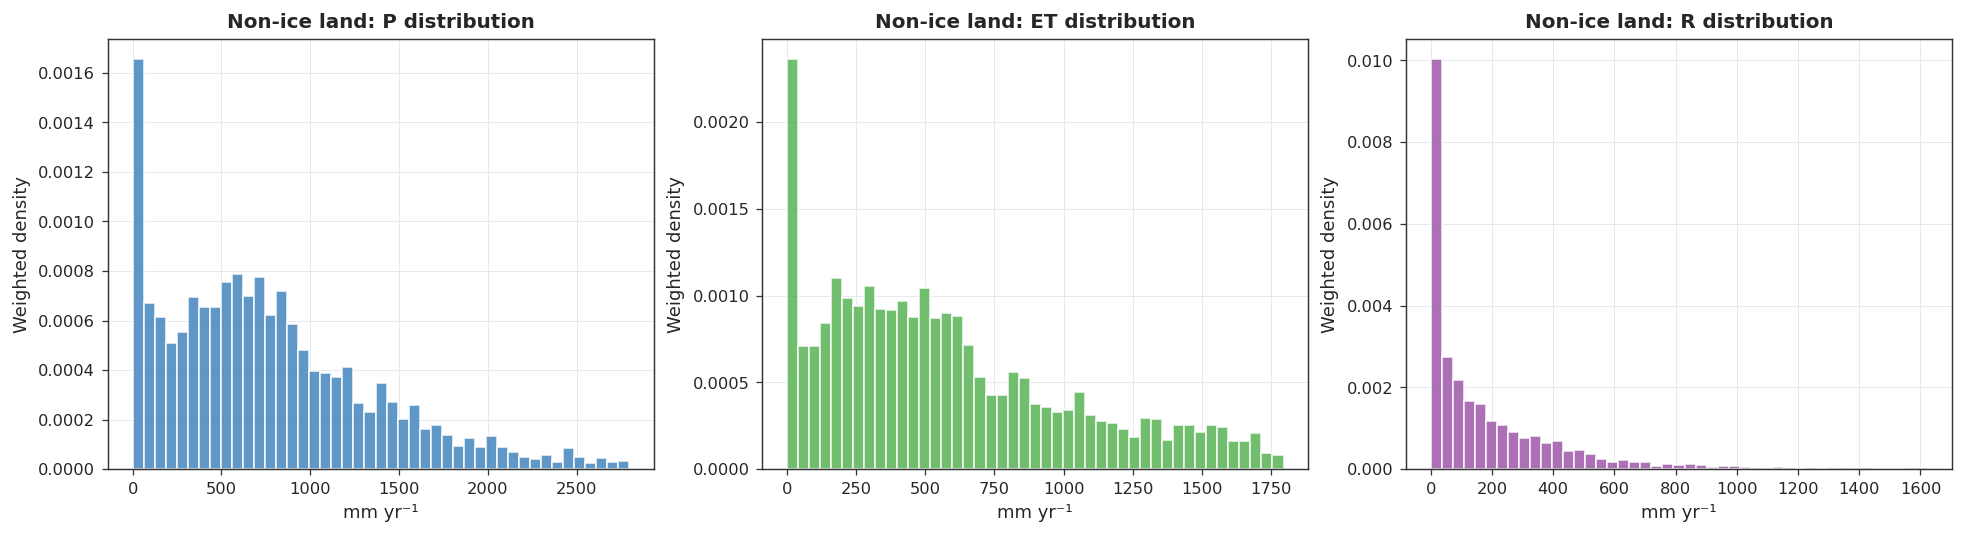

In [8]:
def weighted_quantile(values, weights, probabilities=(0.05, 0.25, 0.5, 0.75, 0.95)):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values, weights = values[valid], weights[valid]
    if values.size == 0:
        return np.full(len(probabilities), np.nan)
    order = np.argsort(values)
    values, weights = values[order], weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative /= weights.sum()
    return np.interp(probabilities, cumulative, values)

def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return np.average(values[valid], weights=weights[valid]) if valid.any() else np.nan

def summarize_group(frame, label):
    rows = []
    for variable in ["P", "ET", "R", "WB", "ET_over_P", "R_over_P"]:
        q05, q25, q50, q75, q95 = weighted_quantile(frame[variable], frame["land_area"])
        rows.append({
            "region": label, "variable": variable, "cells": len(frame),
            "area_million_km2": frame["land_area"].sum() / 1e12,
            "weighted_mean": weighted_mean(frame[variable], frame["land_area"]),
            "q05": q05, "q25": q25, "median": q50, "q75": q75, "q95": q95,
        })
    return rows

summary_rows = []
for domain_name, domain_frame in domain_frames.items():
    summary_rows.extend(summarize_group(domain_frame, domain_name))
if zone_available:
    for label in ZONE_ORDER:
        summary_rows.extend(summarize_group(analysis_df.loc[analysis_df["zone"] == label], label))
summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, variable, color in zip(axes, ["P", "ET", "R"], ["#377eb8", "#4daf4a", "#984ea3"]):
    values = analysis_df[variable].to_numpy()
    weights = analysis_df["land_area"].to_numpy()
    upper = np.nanquantile(values, 0.995)
    keep = np.isfinite(values) & (values <= upper)
    ax.hist(values[keep], bins=45, weights=weights[keep], density=True, color=color, alpha=0.8)
    style_cartesian_axes(ax)
    ax.set_title(f"Non-ice land: {variable} distribution")
    ax.set_xlabel("mm yr⁻¹")
    ax.set_ylabel("Weighted density")
plt.show()


## Step 8 — Functional relationships: P–ET, P–R, and water closure

### 中文详细说明

这一部分仍属于数据处理后的关系诊断，不建立 tree。相关表先比较 All land、Non-ice land 和 Land ice；散点图使用主要的 Non-ice land 分析域，避免冰盖过程主导普通陆地关系。分析三组关系：

- **P–ET**：降水增加时蒸散如何响应；
- **P–R**：降水增加到什么范围后径流明显增加；
- **P–(ET+R)**：长期水量输出是否接近降水输入，即水量闭合情况。

每张图包含原始网格散点、1:1参考线和按 P 分箱后的面积加权中位数。分箱曲线比一条全局线性回归更适合显示非线性和阈值。若 Köppen 分区可用，还会绘制 WW、WD、CW、CD 各自的 P–ET 图。

预期关注的现象包括：

- WD 中 ET 是否更接近 P，说明水分限制较强；
- WW 中 P 很高后 ET 是否趋于饱和、更多水量转为径流；
- CW 中相同 P 下 ET 是否较低，暗示能量限制；
- CD 是否集中在低 P、低 ET、低 R；
- 不同区域的 tree 可能在哪些 P 范围产生不同分裂阈值。

表格同时报告 Pearson、Spearman 和面积加权 Pearson。若 Spearman 明显高于 Pearson，说明关系可能强但非线性。不过当前只有 P 一个解释变量，不能把结果解释为完整因果关系：温度、净辐射、植被、土壤储水和积雪过程仍未进入分析。

These plots remain part of data diagnostics; no tree is fitted here. The correlation table contrasts all land, non-ice land, and land ice, while the scatter plots use the primary non-ice domain. They ask whether additional precipitation is primarily associated with higher ET or higher runoff.

The analysis reports Pearson correlation, Spearman rank correlation, and an area-weighted Pearson correlation. Scatter plots include area-weighted binned medians rather than relying only on a global regression line.

Interpretation remains associational: with only P as the explanatory variable, energy limitation, temperature, vegetation, storage, and snow processes are not explicitly represented.


,region,pair,n,Pearson,Spearman,weighted_Pearson
0,All land,P–ET,6222,0.902,0.868,0.907
1,All land,P–R,6222,0.742,0.792,0.728
2,All land,ET–R,6222,0.453,0.803,0.410
3,Non-ice land,P–ET,4172,0.888,0.906,0.909
4,Non-ice land,P–R,4172,0.698,0.720,0.717
5,Non-ice land,ET–R,4172,0.291,0.432,0.361
6,Land ice,P–ET,2050,0.411,0.260,0.381
7,Land ice,P–R,2050,NaN,NaN,NaN
8,Land ice,ET–R,2050,NaN,NaN,NaN


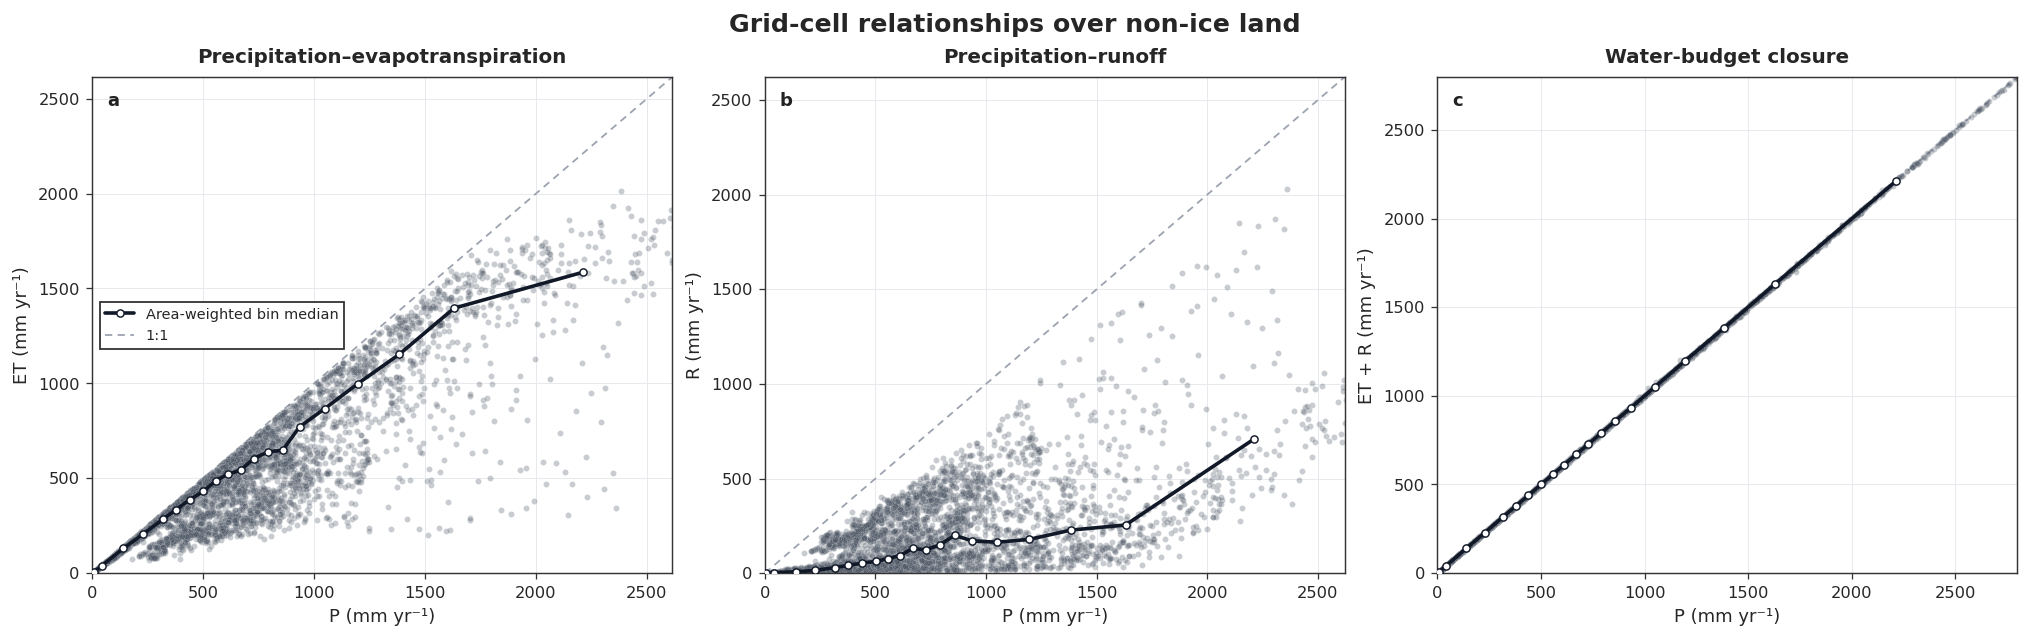

In [9]:
def weighted_corr(x, y, weights):
    x, y, weights = map(lambda z: np.asarray(z, dtype=float), (x, y, weights))
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(weights) & (weights > 0)
    x, y, weights = x[valid], y[valid], weights[valid]
    mx, my = np.average(x, weights=weights), np.average(y, weights=weights)
    covariance = np.average((x - mx) * (y - my), weights=weights)
    variance_x = np.average((x - mx) ** 2, weights=weights)
    variance_y = np.average((y - my) ** 2, weights=weights)
    denominator = np.sqrt(variance_x * variance_y)
    return covariance / denominator if denominator > 0 else np.nan

def relationship_stats(frame, region):
    rows = []
    for xvar, yvar in [("P", "ET"), ("P", "R"), ("ET", "R")]:
        valid = frame[[xvar, yvar, "land_area"]].dropna()
        has_variation = valid[xvar].nunique() > 1 and valid[yvar].nunique() > 1
        rows.append({
            "region": region, "pair": f"{xvar}–{yvar}", "n": len(valid),
            "Pearson": pearsonr(valid[xvar], valid[yvar]).statistic if has_variation else np.nan,
            "Spearman": spearmanr(valid[xvar], valid[yvar]).statistic if has_variation else np.nan,
            "weighted_Pearson": weighted_corr(valid[xvar], valid[yvar], valid["land_area"]) if has_variation else np.nan,
        })
    return rows

relationship_rows = []
for domain_name, domain_frame in domain_frames.items():
    relationship_rows.extend(relationship_stats(domain_frame, domain_name))
if zone_available:
    for label in ZONE_ORDER:
        relationship_rows.extend(relationship_stats(analysis_df.loc[analysis_df["zone"] == label], label))
relationship_df = pd.DataFrame(relationship_rows)
display(relationship_df.round(3))

def binned_weighted_medians(frame, xvar, yvar, bins=20):
    work = frame[[xvar, yvar, "land_area"]].dropna().copy()
    edges = np.unique(np.quantile(work[xvar], np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return pd.DataFrame(columns=[xvar, yvar])
    work["bin"] = pd.cut(work[xvar], edges, include_lowest=True, duplicates="drop")
    points = []
    for _, group in work.groupby("bin", observed=True):
        points.append({
            xvar: weighted_quantile(group[xvar], group["land_area"], [0.5])[0],
            yvar: weighted_quantile(group[yvar], group["land_area"], [0.5])[0],
        })
    return pd.DataFrame(points)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8), constrained_layout=True)
plot_pairs = [("P", "ET"), ("P", "R"), ("P", "ET_plus_R")]
plot_frame = analysis_df.copy()
plot_frame["ET_plus_R"] = plot_frame["ET"] + plot_frame["R"]
scatter_titles = ["Precipitation–evapotranspiration", "Precipitation–runoff", "Water-budget closure"]
for panel, (ax, (xvar, yvar), title) in enumerate(zip(axes, plot_pairs, scatter_titles)):
    style_cartesian_axes(ax)
    if zone_available:
        for label in ZONE_ORDER:
            sub = plot_frame.loc[plot_frame["zone"] == label]
            ax.scatter(sub[xvar], sub[yvar], s=11, alpha=0.34, color=ZONE_COLORS[label],
                       edgecolors="white", linewidths=0.18, label=label, rasterized=True, zorder=2)
    else:
        ax.scatter(plot_frame[xvar], plot_frame[yvar], s=11, alpha=0.30, color="#4B5563",
                   edgecolors="white", linewidths=0.18, rasterized=True, zorder=2)
    binned = binned_weighted_medians(plot_frame, xvar, yvar)
    ax.plot(binned[xvar], binned[yvar], color="#111827", lw=2.0, marker="o", ms=4,
            markerfacecolor="white", markeredgecolor="#111827", markeredgewidth=0.8,
            label="Area-weighted bin median", zorder=4)
    upper = np.nanquantile(np.r_[plot_frame[xvar].values, plot_frame[yvar].values], 0.995)
    ax.plot([0, upper], [0, upper], ls=(0, (4, 3)), lw=1.0, color="#9CA3AF", label="1:1", zorder=1)
    ax.set_xlim(left=0, right=upper)
    ax.set_ylim(bottom=min(0, np.nanquantile(plot_frame[yvar], 0.005)), top=upper)
    ax.set_xlabel(f"{xvar} (mm yr⁻¹)")
    ax.set_ylabel(f"{yvar.replace('_plus_', ' + ')} (mm yr⁻¹)")
    ax.set_title(title, pad=8)
    ax.text(0.025, 0.97, chr(97 + panel), transform=ax.transAxes, va="top", ha="left",
            fontsize=10, fontweight="bold", color="#222222")
axes[0].legend(frameon=True, fancybox=False, facecolor="white", edgecolor="#333333", framealpha=1, fontsize=8)
fig.suptitle("Grid-cell relationships over non-ice land", fontsize=14, fontweight="semibold")
plt.show()

if zone_available:
    fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
    for panel, (ax, label) in enumerate(zip(axes.ravel(), ZONE_ORDER)):
        style_cartesian_axes(ax)
        sub = analysis_df.loc[analysis_df["zone"] == label]
        ax.scatter(sub["P"], sub["ET"], s=12, alpha=0.38, color=ZONE_COLORS[label],
                   edgecolors="white", linewidths=0.20, rasterized=True, zorder=2)
        binned = binned_weighted_medians(sub, "P", "ET", bins=15)
        ax.plot(binned["P"], binned["ET"], color="#111827", lw=2, marker="o", ms=4,
                markerfacecolor="white", markeredgecolor="#111827", markeredgewidth=0.8, zorder=4)
        upper = np.nanquantile(np.r_[sub["P"], sub["ET"]], 0.995)
        ax.plot([0, upper], [0, upper], ls=(0, (4, 3)), color="#9CA3AF", lw=1, zorder=1)
        ax.set_xlim(0, upper)
        ax.set_ylim(min(0, sub["ET"].quantile(0.005)), upper)
        ax.set_title(f"{label}: P–ET")
        ax.set_xlabel("P (mm yr⁻¹)")
        ax.set_ylabel("ET (mm yr⁻¹)")
        ax.text(0.025, 0.97, chr(97 + panel), transform=ax.transAxes, va="top", ha="left",
                fontsize=10, fontweight="bold", color="#222222")
    fig.suptitle("Precipitation–evapotranspiration relationships by climate region", fontsize=14, fontweight="semibold")
    plt.show()


## Step 9 — Annual variability and mean seasonal cycle

### 中文详细说明

前面的30年气候平均主要研究不同网格之间的空间差异，这一步补充时间维度。首先计算1985–2014每一年的面积加权 P、ET 和 R，并同时得到年度 $P-ET-R$。这可以检查：

- 年际变化是否合理；
- P 的湿年和干年是否对应 ET、R 的同步变化；
- 径流是否比蒸散具有更强的年际波动；
- 是否存在某一年突然跳变，提示缺测或处理错误。

随后计算12个月平均季节循环。这里把原始通量乘86400转换为 `mm/day`，而不是直接画 `mm/month`，避免31天月份仅因天数更多而显得数值更大。All land、Non-ice land 和 Land ice 分别绘制 P、ET、R 的月变化；如果 Köppen 分区可用，再追加各气候区，用于观察降水峰值、蒸散峰值、径流响应及可能的季节滞后。

这一阶段先不急着做趋势显著性检验。应先确认时间序列结构、异常年份和季节循环没有问题，再决定是否分析趋势或月尺度滞后关系。

The climatological grid-cell analysis describes spatial co-variability. This step adds two temporal views:

- area-weighted annual P, ET, and runoff over the primary non-ice domain for 1985–2014
- all-land, non-ice-land, and land-ice 12-month climatological cycles expressed as mean daily rate (`mm day⁻¹`)

Using a daily rate for the seasonal cycle prevents longer months from appearing artificially larger. Regional seasonal cycles are plotted only when Köppen zones are available. Trend testing is intentionally deferred until the basic temporal structure and anomalies have been inspected.


,P,ET,R,P_minus_ET_minus_R
count,30.000,30.000,30.000,30.000
mean,779.121,585.926,192.962,0.234
std,16.416,9.191,6.971,6.103
min,743.183,568.561,177.143,-11.077
25%,765.458,578.613,190.447,-3.183
50%,778.333,585.850,192.787,-0.932
75%,790.940,590.736,196.184,3.683
max,809.845,604.734,207.597,14.448


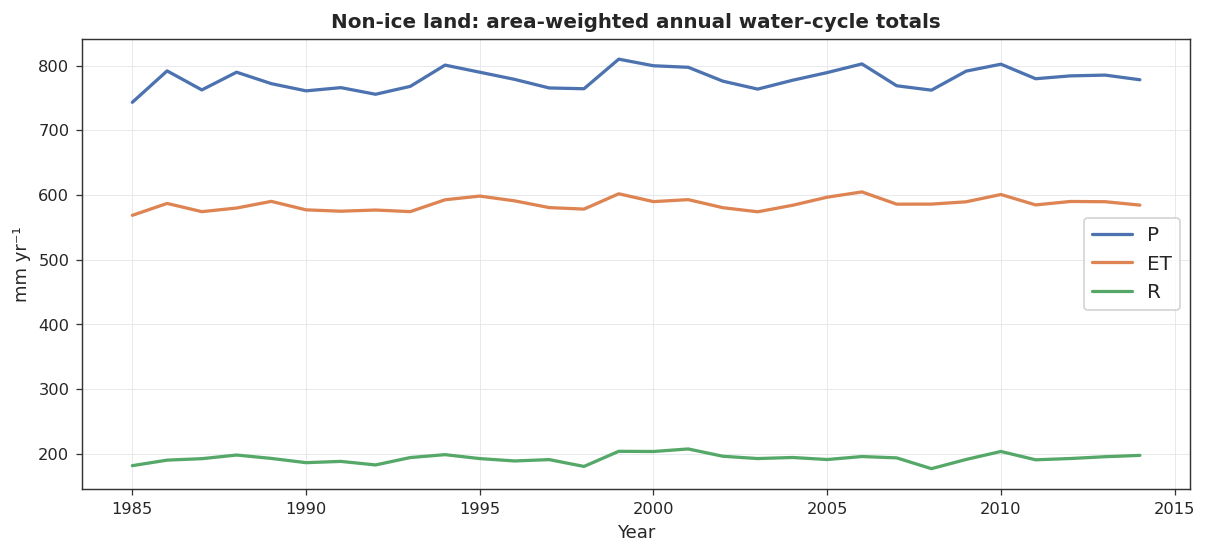

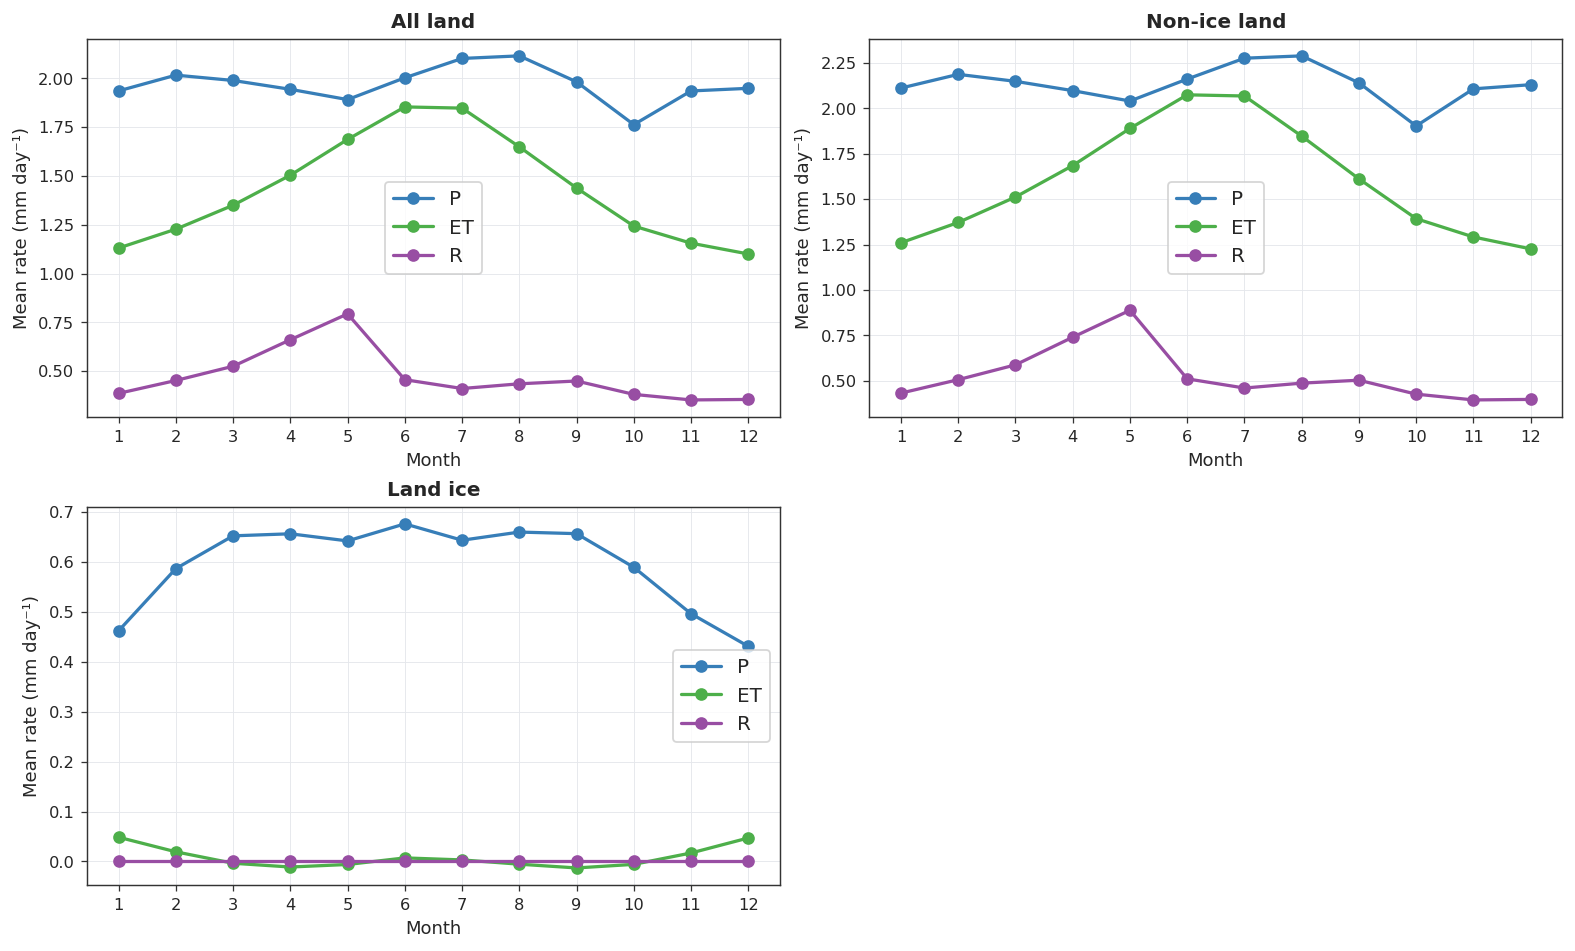

In [10]:
def area_weighted_spatial_mean(da, mask):
    weights = land_area.where(mask, 0)
    return (da.where(mask) * weights).sum(("lat", "lon"), skipna=True) / weights.sum(("lat", "lon"))

annual_series = pd.DataFrame({
    "P": area_weighted_spatial_mean(P_annual, analysis_mask).to_series(),
    "ET": area_weighted_spatial_mean(ET_annual, analysis_mask).to_series(),
    "R": area_weighted_spatial_mean(R_annual, analysis_mask).to_series(),
})
annual_series["P_minus_ET_minus_R"] = annual_series["P"] - annual_series["ET"] - annual_series["R"]
display(annual_series.describe().round(3))

fig, ax = plt.subplots(figsize=(11, 4.5))
annual_series[["P", "ET", "R"]].plot(ax=ax, lw=1.8)
style_cartesian_axes(ax)
ax.set_title("Non-ice land: area-weighted annual water-cycle totals")
ax.set_xlabel("Year")
ax.set_ylabel("mm yr⁻¹")
plt.show()

P_daily_rate = (P_flux.sel(time=slice(f"{START_YEAR}-01-01", f"{END_YEAR}-12-31")) * 86400).groupby("time.month").mean("time")
ET_daily_rate = (ET_flux.sel(time=slice(f"{START_YEAR}-01-01", f"{END_YEAR}-12-31")) * 86400).groupby("time.month").mean("time")
R_daily_rate = (R_flux.sel(time=slice(f"{START_YEAR}-01-01", f"{END_YEAR}-12-31")) * 86400).groupby("time.month").mean("time")

seasonal_regions = [("All land", land_mask), ("Non-ice land", non_ice_mask), ("Land ice", ice_mask)]
if zone_available:
    seasonal_regions.extend((label, analysis_mask & (zone == label)) for label in ZONE_ORDER)

n_panels = len(seasonal_regions)
ncols = 2 if n_panels > 1 else 1
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.6 * nrows), squeeze=False, constrained_layout=True)
for ax, (label, mask) in zip(axes.ravel(), seasonal_regions):
    style_cartesian_axes(ax)
    for da, name, color in [(P_daily_rate, "P", "#377eb8"), (ET_daily_rate, "ET", "#4daf4a"), (R_daily_rate, "R", "#984ea3")]:
        series = area_weighted_spatial_mean(da, mask)
        ax.plot(series.month, series, marker="o", lw=1.8, label=name, color=color)
    ax.set_title(label)
    ax.set_xticks(range(1, 13))
    ax.set_xlabel("Month")
    ax.set_ylabel("Mean rate (mm day⁻¹)")
    ax.legend()
for ax in axes.ravel()[n_panels:]:
    ax.set_visible(False)
plt.show()


## Step 10 — Analysis-ready non-ice grid table

### 中文详细说明

最后一步整理一行一网格的分析表，但本 notebook 不建立 tree。主要分析域是 Non-ice land；All land 和 Land ice 仍保留在前面的完整 `grid_df` 中，用于敏感性比较。

输出字段包括经纬度、`surface_class`、可选 Köppen proxy、`sftlf`、`sftgif`、网格面积、有效陆地面积、P、ET、R、水量残差、ET/P、R/P 以及全部 QC flags。这样后续无需重新读取和转换原始通量，也不会因为当前 EDA 提前删除异常过程。

第一版数据处理完成的判断标准是：

1. 所有文件、单位、时间和坐标一致；
2. 0–360° 与 −180–180° 经度已经统一；
3. All land、Non-ice land 和 Land ice 的网格数及面积得到核对；
4. 负 ET、零径流和大残差在冰盖与非冰盖域分别统计；
5. P、ET、R 地图、分布、年度变化与季节循环没有明显处理错误；
6. 分析表保留必要 QC 信息，而不是按照结果变量提前删点。

默认 `SAVE_TABLE=False`，因此执行 notebook 不会写出派生 CSV。只有人工改为 True 时，才会把 Non-ice land 分析表保存到 `caseA/derived`。

The final block creates an analysis-ready, one-row-per-grid-cell table but does not fit a tree. Non-ice land is the primary domain; the complete all-land and land-ice frames remain available earlier in the notebook for sensitivity checks.

The table retains coordinates, surface class, optional Köppen proxy, `sftlf`, `sftgif`, cell and land area, P, ET, runoff, water-balance metrics, local ratios, and QC flags. No observations are removed using precipitation magnitude, negative ET, zero runoff, or a large residual.

The optional export writes only the non-ice analysis rows and is disabled by default.


In [11]:
analysis_columns = [
    "lat", "lon", "surface_class", "zone", "land_fraction", "land_ice_fraction",
    "cell_area", "land_area", "P", "ET", "R", "WB", "ET_over_P", "R_over_P",
    "negative_ET", "zero_R", "ET_greater_than_P", "large_WB",
]
analysis_ready_df = analysis_df[analysis_columns].replace([np.inf, -np.inf], np.nan).dropna(subset=["P", "ET", "R", "land_area"]).copy()

final_summary = pd.Series({
    "period": f"{START_YEAR}–{END_YEAR}",
    "primary_domain": "Non-ice land",
    "analysis_ready_rows": len(analysis_ready_df),
    "zones_available": zone_available,
    "analysis_area_million_km2": analysis_ready_df["land_area"].sum() / 1e12,
    "negative_ET_rows_retained_for_review": int(analysis_ready_df["negative_ET"].sum()),
    "ET_greater_than_P_rows_retained_for_review": int(analysis_ready_df["ET_greater_than_P"].sum()),
})
display(final_summary.to_frame("value"))
display(analysis_ready_df.head())

if SAVE_TABLE:
    output_dir = CASE_DIR / "derived"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"MPI_ESM1_2_LR_water_cycle_{START_YEAR}_{END_YEAR}_analysis_ready.csv"
    analysis_ready_df.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")
else:
    print("SAVE_TABLE=False: no derived table was written.")


,value
period,1985–2014
primary_domain,Non-ice land
analysis_ready_rows,4172
zones_available,False
analysis_area_million_km2,131.334337
negative_ET_rows_retained_for_review,0
ET_greater_than_P_rows_retained_for_review,44


,lat,lon,surface_class,zone,land_fraction,land_ice_fraction,cell_area,land_area,P,ET,R,WB,ET_over_P,R_over_P,negative_ET,zero_R,ET_greater_than_P,large_WB
3515,-55.024808,-69.375,Non-ice land,Not available,100.0,0.0,2.478351e+10,2.478351e+10,1283.297128,600.391758,682.761591,0.143778,0.467851,0.532037,False,False,False,False
3516,-55.024808,-67.500,Non-ice land,Not available,100.0,0.0,2.478351e+10,2.478351e+10,1050.722948,581.723513,468.916816,0.082618,0.553641,0.446280,False,False,False,False
3705,-53.159595,-73.125,Non-ice land,Not available,100.0,0.0,2.592378e+10,2.592378e+10,1668.252199,734.953865,933.258896,0.039438,0.440553,0.559423,False,False,False,False
3706,-53.159595,-71.250,Non-ice land,Not available,100.0,0.0,2.592378e+10,2.592378e+10,1370.924318,791.946882,578.165683,0.811753,0.577674,0.421734,False,False,False,False
3707,-53.159595,-69.375,Non-ice land,Not available,100.0,0.0,2.592378e+10,2.592378e+10,1084.410305,933.373988,151.007348,0.028969,0.860720,0.139253,False,False,False,False


SAVE_TABLE=False: no derived table was written.
